In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [3]:
project_path = Path.cwd().parent

cleaned_path = project_path / "data" / "processed" / "netflix_cleaned.csv"

df = pd.read_csv(cleaned_path)

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_minutes,duration_seasons
0,s1,TV Show,3%,Not Specified,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,NaN,4.0
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,93.0,NaN
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",78.0,NaN
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",80.0,NaN
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01,2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...,123.0,NaN


In [4]:
project_path = Path.cwd().parent

cleaned_path = project_path / "data" / "processed" / "netflix_cleaned.csv"

df = pd.read_csv(cleaned_path)

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_minutes,duration_seasons
0,s1,TV Show,3%,Not Specified,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,NaN,4.0
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,93.0,NaN
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",78.0,NaN
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",80.0,NaN
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01,2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...,123.0,NaN


In [5]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (7787, 14)
Columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description', 'duration_minutes', 'duration_seasons']


In [6]:
content_type_counts = df['type'].value_counts()

print(content_type_counts)

type
Movie      5377
TV Show    2410
Name: count, dtype: int64


In [7]:
content_type_percentage = df['type'].value_counts(normalize=True) * 100

print(content_type_percentage.round(2))

type
Movie      69.05
TV Show    30.95
Name: proportion, dtype: float64


In [8]:
content_summary = pd.DataFrame({
    'Count': content_type_counts,
    'Percentage': content_type_percentage.round(2)
})

content_summary

,Count,Percentage
type,,
Movie,5377,69.05
TV Show,2410,30.95


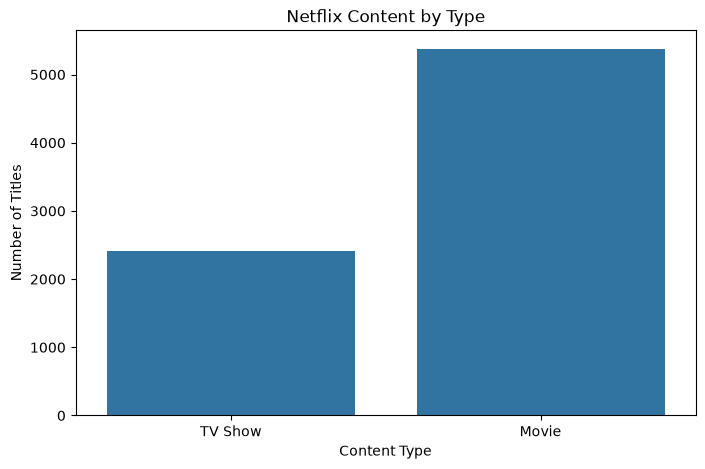

In [9]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='type')

plt.title('Netflix Content by Type')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')

plt.show()

In [10]:
visualization_path = project_path / "visualizations"

visualization_path.mkdir(exist_ok=True)

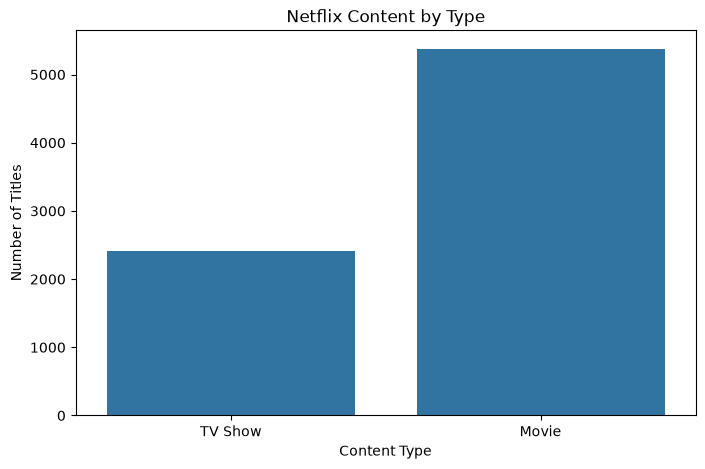

In [11]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='type')

plt.title('Netflix Content by Type')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')

plt.savefig(
    visualization_path / "content_by_type.png",
    bbox_inches='tight'
)

plt.show()

In [12]:
content_by_year = (
    df.groupby(['release_year', 'type'])
      .size()
      .reset_index(name='count')
)

content_by_year.head(10)

,release_year,type,count
0,1925,TV Show,1
1,1942,Movie,2
2,1943,Movie,3
3,1944,Movie,3
4,1945,Movie,3
5,1946,Movie,1
6,1946,TV Show,1
7,1947,Movie,1
8,1954,Movie,2
9,1955,Movie,3


In [13]:
year_totals = (
    df['release_year']
    .value_counts()
    .sort_index()
)

year_totals.tail(10)

release_year
2012     219
2013     267
2014     334
2015     541
2016     882
2017    1012
2018    1121
2019     996
2020     868
2021      31
Name: count, dtype: int64

In [15]:
top_release_years = (
    df['release_year']
    .value_counts()
    .sort_values(ascending=False)
    .head(10)
)

top_release_years

release_year
2018    1121
2017    1012
2019     996
2016     882
2020     868
2015     541
2014     334
2013     267
2012     219
2010     173
Name: count, dtype: int64

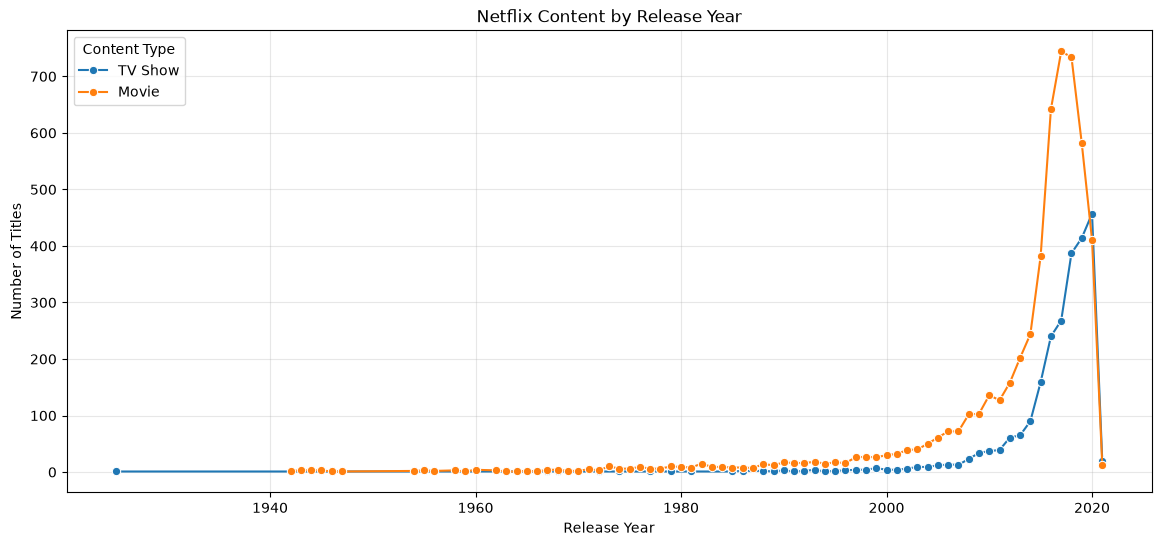

In [16]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=content_by_year,
    x='release_year',
    y='count',
    hue='type',
    marker='o'
)

plt.title('Netflix Content by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.legend(title='Content Type')
plt.grid(alpha=0.3)

plt.show()

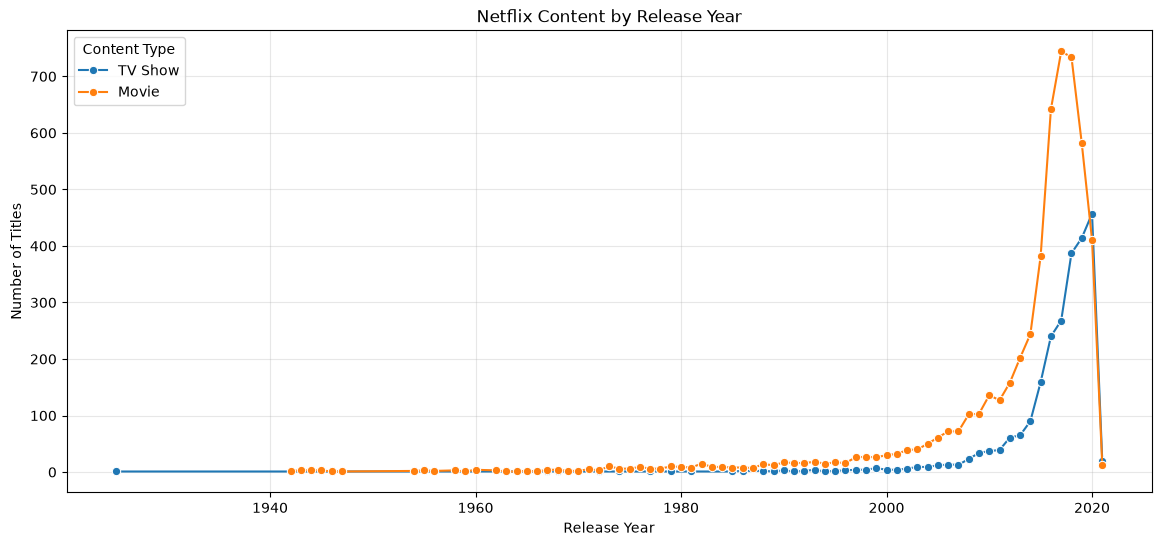

In [17]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=content_by_year,
    x='release_year',
    y='count',
    hue='type',
    marker='o'
)

plt.title('Netflix Content by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.legend(title='Content Type')
plt.grid(alpha=0.3)

plt.savefig(
    visualization_path / 'content_by_release_year.png',
    bbox_inches='tight'
)

plt.show()

In [18]:
top_release_years

release_year
2018    1121
2017    1012
2019     996
2016     882
2020     868
2015     541
2014     334
2013     267
2012     219
2010     173
Name: count, dtype: int64

In [19]:
df['date_added_year'] = pd.to_datetime(
    df['date_added'],
    errors='coerce'
).dt.year

In [20]:
added_by_year = (
    df['date_added_year']
    .value_counts()
    .sort_index()
)

added_by_year

date_added_year
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      25
2015.0      88
2016.0     443
2017.0    1225
2018.0    1685
2019.0    2153
2020.0    2009
2021.0     117
Name: count, dtype: int64

In [21]:
top_added_years = (
    added_by_year
    .sort_values(ascending=False)
    .head(10)
)

top_added_years

date_added_year
2019.0    2153
2020.0    2009
2018.0    1685
2017.0    1225
2016.0     443
2021.0     117
2015.0      88
2014.0      25
2011.0      13
2013.0      11
Name: count, dtype: int64

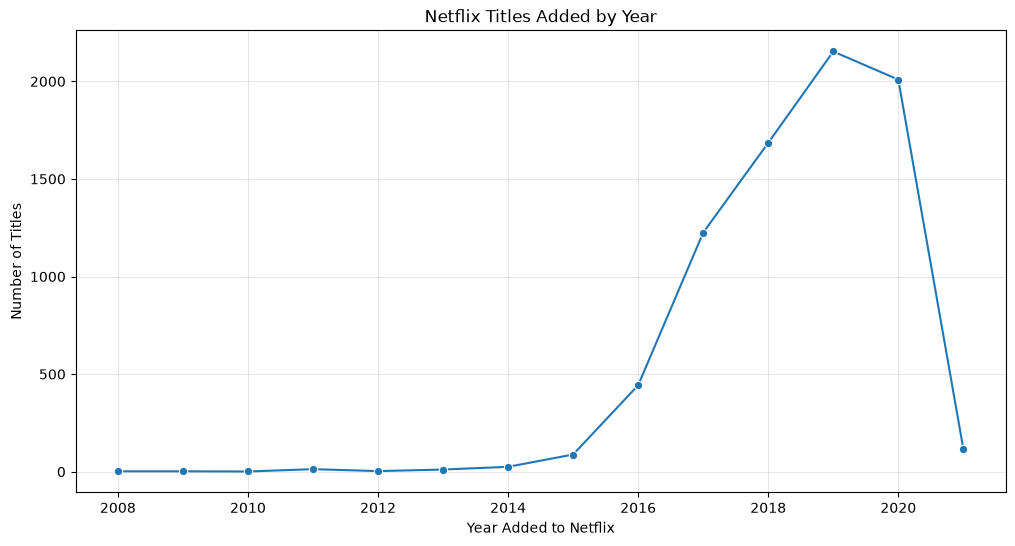

In [22]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    x=added_by_year.index,
    y=added_by_year.values,
    marker='o'
)

plt.title('Netflix Titles Added by Year')
plt.xlabel('Year Added to Netflix')
plt.ylabel('Number of Titles')
plt.grid(alpha=0.3)

plt.show()

In [23]:
plt.savefig(
    visualization_path / 'content_added_by_year.png',
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

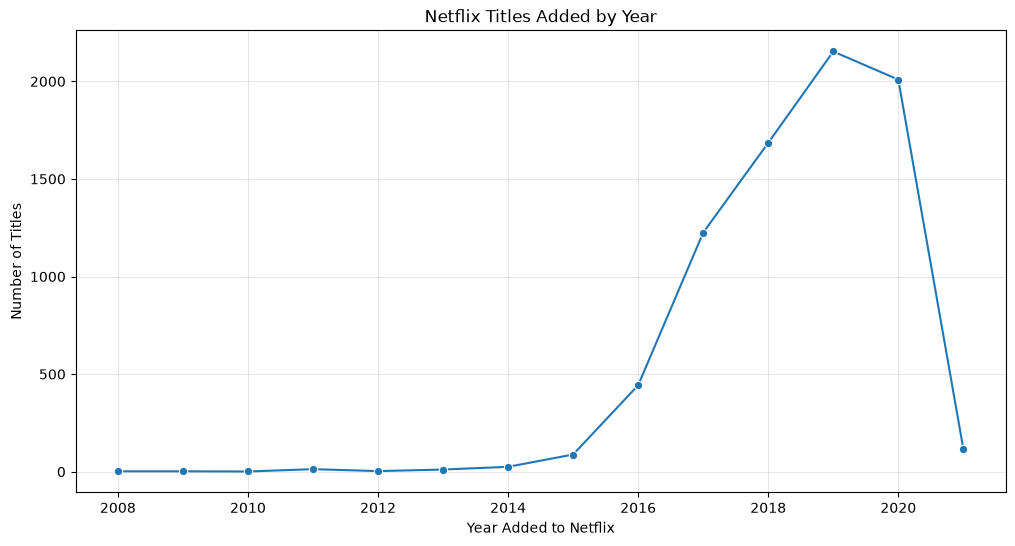

Graph saved successfully at:
c:\Users\shiva\OneDrive\Desktop\Company\DynamixNetworks_Netflix_Analysis\visualizations\netflix_titles_added_by_year.png


In [24]:
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# Project and visualization paths
project_path = Path.cwd().parent
visualization_path = project_path / "visualizations"

# Create folder if it doesn't exist
visualization_path.mkdir(exist_ok=True)

# Create graph
plt.figure(figsize=(12, 6))

sns.lineplot(
    x=added_by_year.index,
    y=added_by_year.values,
    marker='o'
)

plt.title('Netflix Titles Added by Year')
plt.xlabel('Year Added to Netflix')
plt.ylabel('Number of Titles')
plt.grid(alpha=0.3)

# Save graph
graph_path = visualization_path / "netflix_titles_added_by_year.png"

plt.savefig(
    graph_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(f"Graph saved successfully at:\n{graph_path}")

In [25]:
rating_counts = df['rating'].value_counts()

rating_counts

rating
TV-MA        2863
TV-14        1931
TV-PG         806
R             665
PG-13         386
TV-Y          280
TV-Y7         271
PG            247
TV-G          194
NR             84
G              39
Not Rated       7
TV-Y7-FV        6
UR              5
NC-17           3
Name: count, dtype: int64

In [26]:
rating_percentage = (
    df['rating']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

rating_percentage

rating
TV-MA        36.77
TV-14        24.80
TV-PG        10.35
R             8.54
PG-13         4.96
TV-Y          3.60
TV-Y7         3.48
PG            3.17
TV-G          2.49
NR            1.08
G             0.50
Not Rated     0.09
TV-Y7-FV      0.08
UR            0.06
NC-17         0.04
Name: proportion, dtype: float64

In [28]:
rating_summary = pd.DataFrame({
    'Count': rating_counts,
    'Percentage': rating_percentage
})

rating_summary

,Count,Percentage
rating,,
TV-MA,2863,36.77
TV-14,1931,24.80
TV-PG,806,10.35
R,665,8.54
PG-13,386,4.96
TV-Y,280,3.60
TV-Y7,271,3.48
PG,247,3.17
TV-G,194,2.49


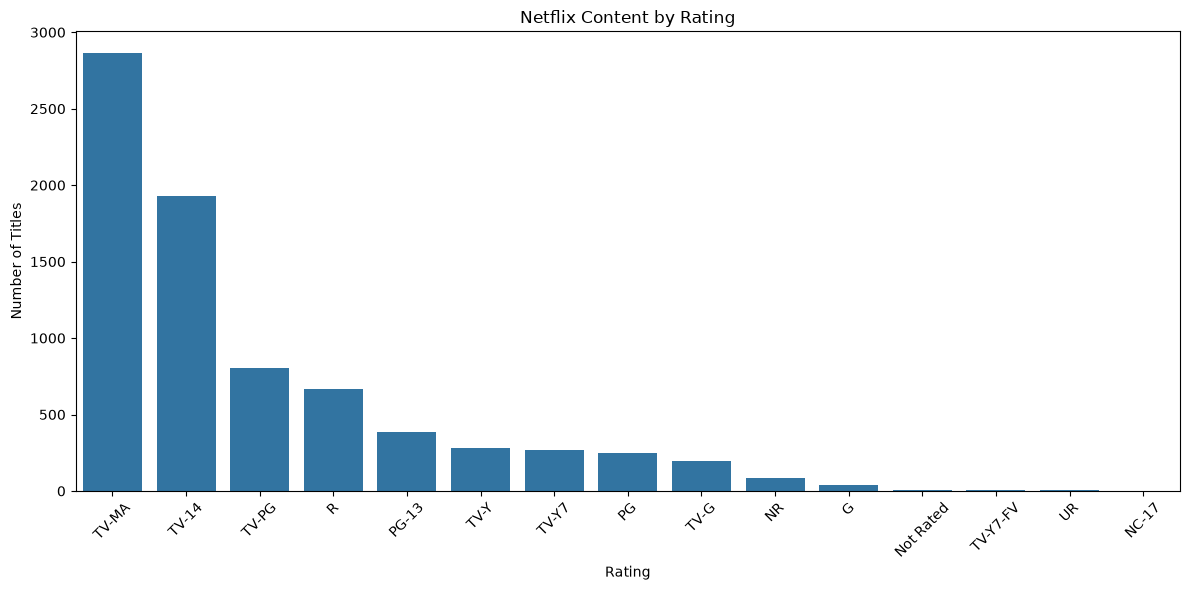

In [29]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=rating_counts.index,
    y=rating_counts.values
)

plt.title('Netflix Content by Rating')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

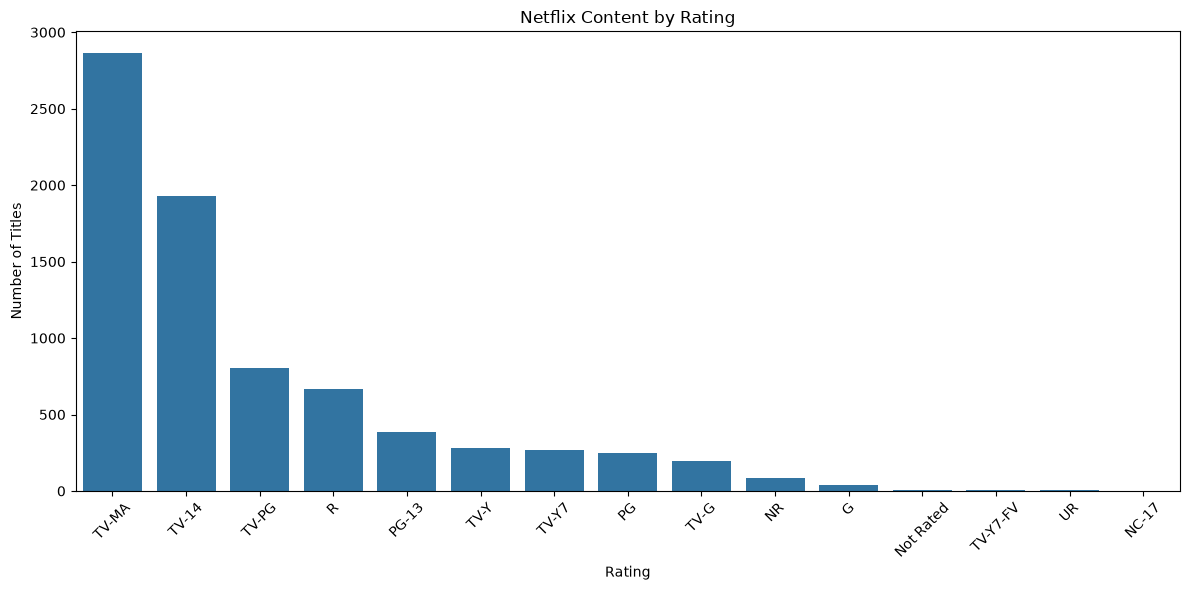

Graph saved successfully at:
c:\Users\shiva\OneDrive\Desktop\Company\DynamixNetworks_Netflix_Analysis\visualizations\netflix_content_by_rating.png


In [30]:
graph_path = visualization_path / "netflix_content_by_rating.png"

plt.figure(figsize=(12, 6))

sns.barplot(
    x=rating_counts.index,
    y=rating_counts.values
)

plt.title('Netflix Content by Rating')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    graph_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(f"Graph saved successfully at:\n{graph_path}")

In [33]:
genre_df = df[['show_id', 'listed_in']].copy()

genre_df['genre'] = genre_df['listed_in'].str.split(',')

genre_df = genre_df.explode('genre')

genre_df['genre'] = genre_df['genre'].str.strip()

genre_df.head(10)

,show_id,listed_in,genre
0,s1,"International TV Shows, TV Dramas, TV Sci-Fi &...",International TV Shows
0,s1,"International TV Shows, TV Dramas, TV Sci-Fi &...",TV Dramas
0,s1,"International TV Shows, TV Dramas, TV Sci-Fi &...",TV Sci-Fi & Fantasy
1,s2,"Dramas, International Movies",Dramas
1,s2,"Dramas, International Movies",International Movies
2,s3,"Horror Movies, International Movies",Horror Movies
2,s3,"Horror Movies, International Movies",International Movies
3,s4,"Action & Adventure, Independent Movies, Sci-Fi...",Action & Adventure
3,s4,"Action & Adventure, Independent Movies, Sci-Fi...",Independent Movies
3,s4,"Action & Adventure, Independent Movies, Sci-Fi...",Sci-Fi & Fantasy


In [34]:
genre_counts = genre_df['genre'].value_counts()

genre_counts.head(15)

genre
International Movies        2437
Dramas                      2106
Comedies                    1471
International TV Shows      1199
Documentaries                786
Action & Adventure           721
TV Dramas                    704
Independent Movies           673
Children & Family Movies     532
Romantic Movies              531
TV Comedies                  525
Thrillers                    491
Crime TV Shows               427
Kids' TV                     414
Docuseries                   353
Name: count, dtype: int64

In [35]:
genre_percentage = (
    genre_counts
    .div(df.shape[0])
    .mul(100)
    .round(2)
)

genre_percentage.head(15)

genre
International Movies        31.30
Dramas                      27.05
Comedies                    18.89
International TV Shows      15.40
Documentaries               10.09
Action & Adventure           9.26
TV Dramas                    9.04
Independent Movies           8.64
Children & Family Movies     6.83
Romantic Movies              6.82
TV Comedies                  6.74
Thrillers                    6.31
Crime TV Shows               5.48
Kids' TV                     5.32
Docuseries                   4.53
Name: count, dtype: float64

In [37]:
genre_summary = pd.DataFrame({
    'Count': genre_counts,
    'Percentage_of_titles': genre_percentage
})

genre_summary.head(15)

,Count,Percentage_of_titles
genre,,
International Movies,2437,31.30
Dramas,2106,27.05
Comedies,1471,18.89
International TV Shows,1199,15.40
Documentaries,786,10.09
Action & Adventure,721,9.26
TV Dramas,704,9.04
Independent Movies,673,8.64
Children & Family Movies,532,6.83


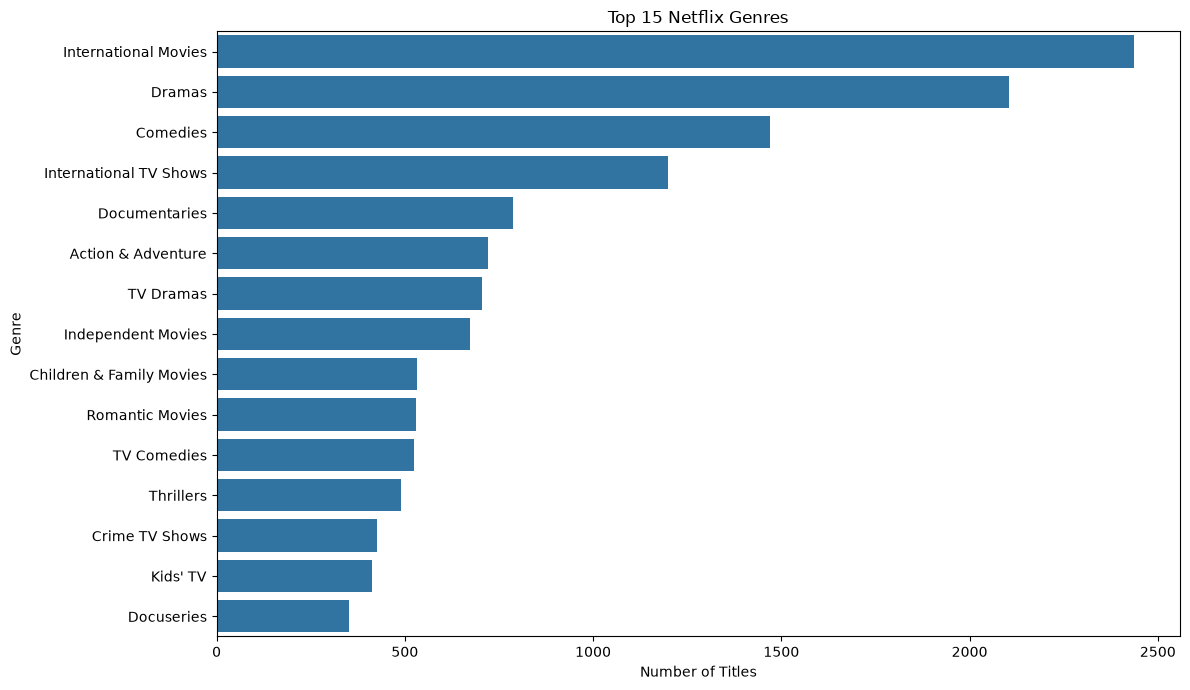

In [38]:
top_genres = genre_counts.head(15)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title('Top 15 Netflix Genres')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')

plt.tight_layout()
plt.show()

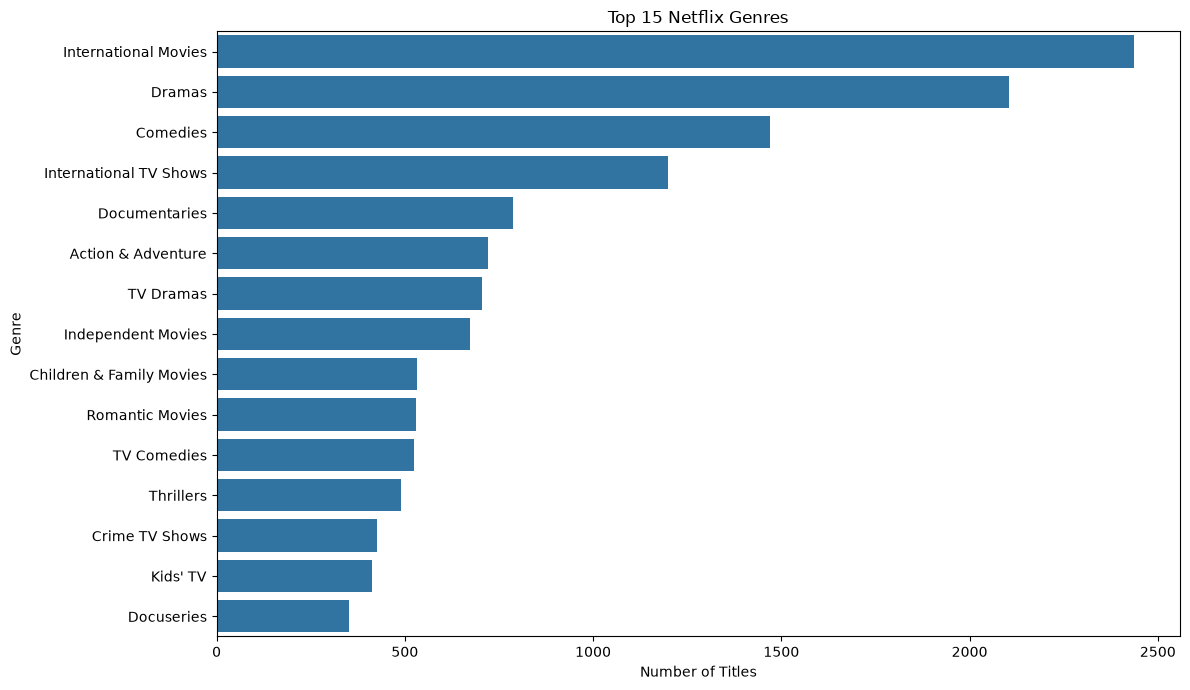

Graph saved successfully at:
c:\Users\shiva\OneDrive\Desktop\Company\DynamixNetworks_Netflix_Analysis\visualizations\top_15_netflix_genres.png


In [39]:
graph_path = visualization_path / "top_15_netflix_genres.png"

plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title('Top 15 Netflix Genres')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')

plt.tight_layout()

plt.savefig(
    graph_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(f"Graph saved successfully at:\n{graph_path}")

In [40]:
genre_percentage = (
    genre_counts
    .div(df.shape[0])
    .mul(100)
    .round(2)
)

genre_percentage.head(15)

genre
International Movies        31.30
Dramas                      27.05
Comedies                    18.89
International TV Shows      15.40
Documentaries               10.09
Action & Adventure           9.26
TV Dramas                    9.04
Independent Movies           8.64
Children & Family Movies     6.83
Romantic Movies              6.82
TV Comedies                  6.74
Thrillers                    6.31
Crime TV Shows               5.48
Kids' TV                     5.32
Docuseries                   4.53
Name: count, dtype: float64

In [41]:
genre_summary = pd.DataFrame({
    'Count': genre_counts,
    'Percentage_of_titles': genre_percentage
})

genre_summary.head(15)

,Count,Percentage_of_titles
genre,,
International Movies,2437,31.30
Dramas,2106,27.05
Comedies,1471,18.89
International TV Shows,1199,15.40
Documentaries,786,10.09
Action & Adventure,721,9.26
TV Dramas,704,9.04
Independent Movies,673,8.64
Children & Family Movies,532,6.83


In [42]:
top_genres = genre_counts.head(15)

top_genres

genre
International Movies        2437
Dramas                      2106
Comedies                    1471
International TV Shows      1199
Documentaries                786
Action & Adventure           721
TV Dramas                    704
Independent Movies           673
Children & Family Movies     532
Romantic Movies              531
TV Comedies                  525
Thrillers                    491
Crime TV Shows               427
Kids' TV                     414
Docuseries                   353
Name: count, dtype: int64

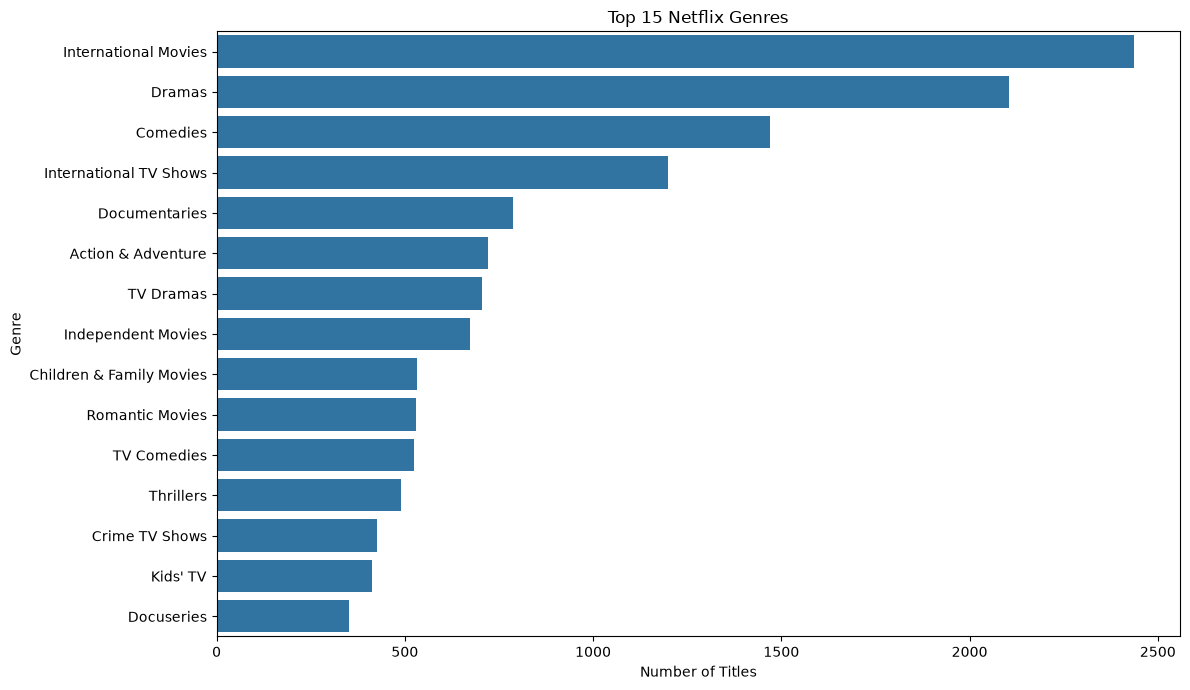

In [43]:
plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title('Top 15 Netflix Genres')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')

plt.tight_layout()
plt.show()

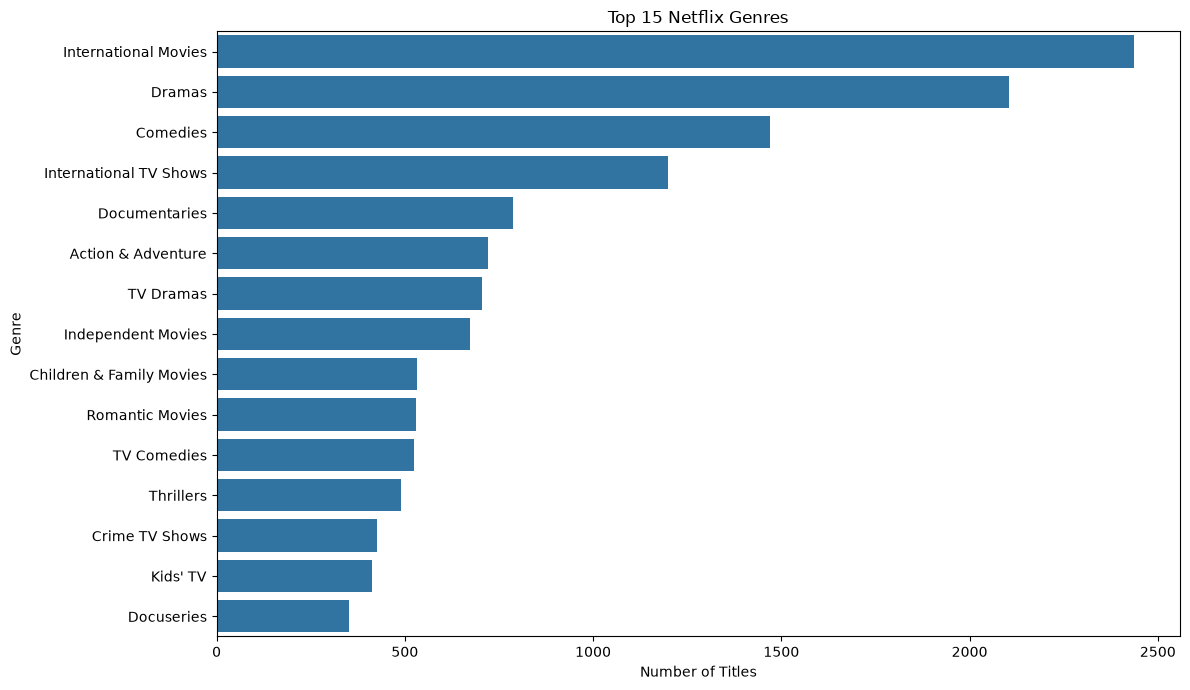

Graph saved successfully at:
c:\Users\shiva\OneDrive\Desktop\Company\DynamixNetworks_Netflix_Analysis\visualizations\top_15_netflix_genres.png


In [44]:
graph_path = visualization_path / "top_15_netflix_genres.png"

plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title('Top 15 Netflix Genres')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')

plt.tight_layout()

plt.savefig(
    graph_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(f"Graph saved successfully at:\n{graph_path}")

In [45]:
top_genres

genre
International Movies        2437
Dramas                      2106
Comedies                    1471
International TV Shows      1199
Documentaries                786
Action & Adventure           721
TV Dramas                    704
Independent Movies           673
Children & Family Movies     532
Romantic Movies              531
TV Comedies                  525
Thrillers                    491
Crime TV Shows               427
Kids' TV                     414
Docuseries                   353
Name: count, dtype: int64

In [46]:
country_df = df[['show_id', 'country']].copy()

country_df['country'] = country_df['country'].str.split(',')

country_df = country_df.explode('country')

country_df['country'] = country_df['country'].str.strip()

In [47]:
country_analysis = country_df[
    country_df['country'] != 'Not Specified'
].copy()

In [48]:
country_analysis = country_df[
    country_df['country'] != 'Not Specified'
].copy()

In [50]:
country_counts = country_analysis['country'].value_counts()

top_countries = country_counts.head(15)

top_countries

country
United States     3297
India              990
United Kingdom     723
Canada             412
France             349
Japan              287
Spain              215
South Korea        212
Germany            199
Mexico             154
China              147
Australia          144
Egypt              110
Turkey             108
Hong Kong          102
Name: count, dtype: int64

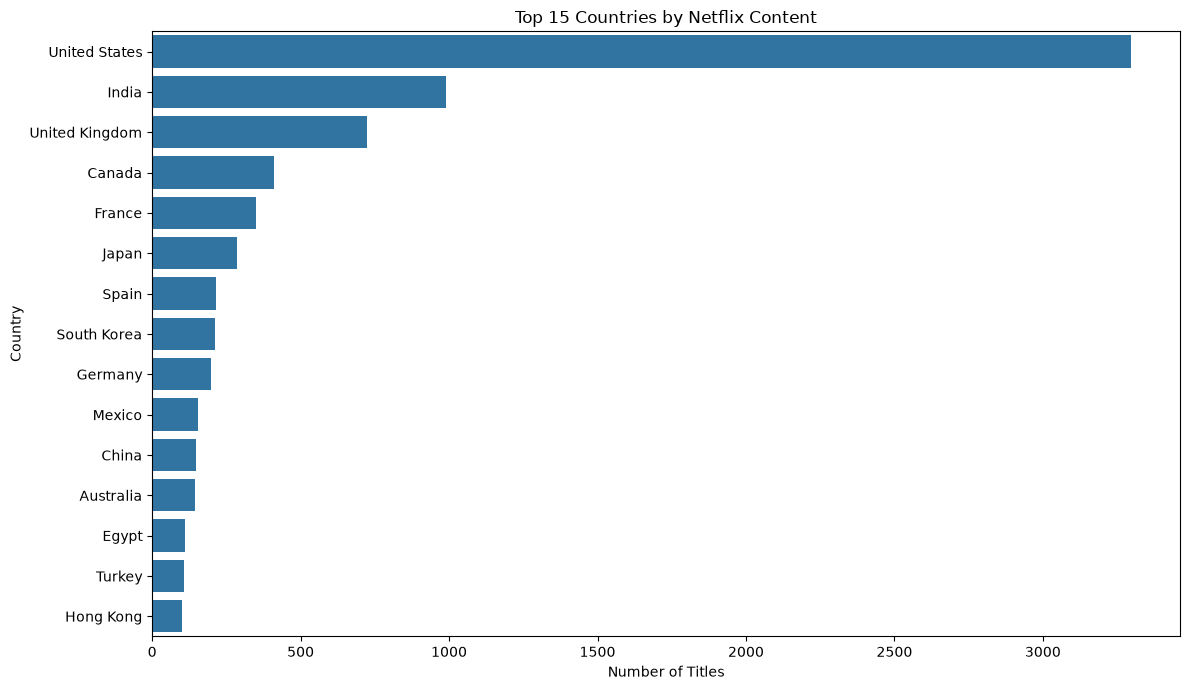

Graph saved successfully at:
c:\Users\shiva\OneDrive\Desktop\Company\DynamixNetworks_Netflix_Analysis\visualizations\top_15_netflix_countries.png


In [51]:
graph_path = visualization_path / "top_15_netflix_countries.png"

plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title('Top 15 Countries by Netflix Content')
plt.xlabel('Number of Titles')
plt.ylabel('Country')

plt.tight_layout()

plt.savefig(
    graph_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(f"Graph saved successfully at:\n{graph_path}")

In [52]:
movie_duration = df[
    (df['type'] == 'Movie') &
    (df['duration_minutes'].notna())
].copy()

movie_duration['duration_minutes'].describe()

count    5377.000000
mean       99.307978
std        28.530881
min         3.000000
25%        86.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_minutes, dtype: float64

In [53]:
print("Average movie duration:",
      round(movie_duration['duration_minutes'].mean(), 2), "minutes")

print("Median movie duration:",
      movie_duration['duration_minutes'].median(), "minutes")

print("Shortest movie:",
      movie_duration['duration_minutes'].min(), "minutes")

print("Longest movie:",
      movie_duration['duration_minutes'].max(), "minutes")

Average movie duration: 99.31 minutes
Median movie duration: 98.0 minutes
Shortest movie: 3.0 minutes
Longest movie: 312.0 minutes


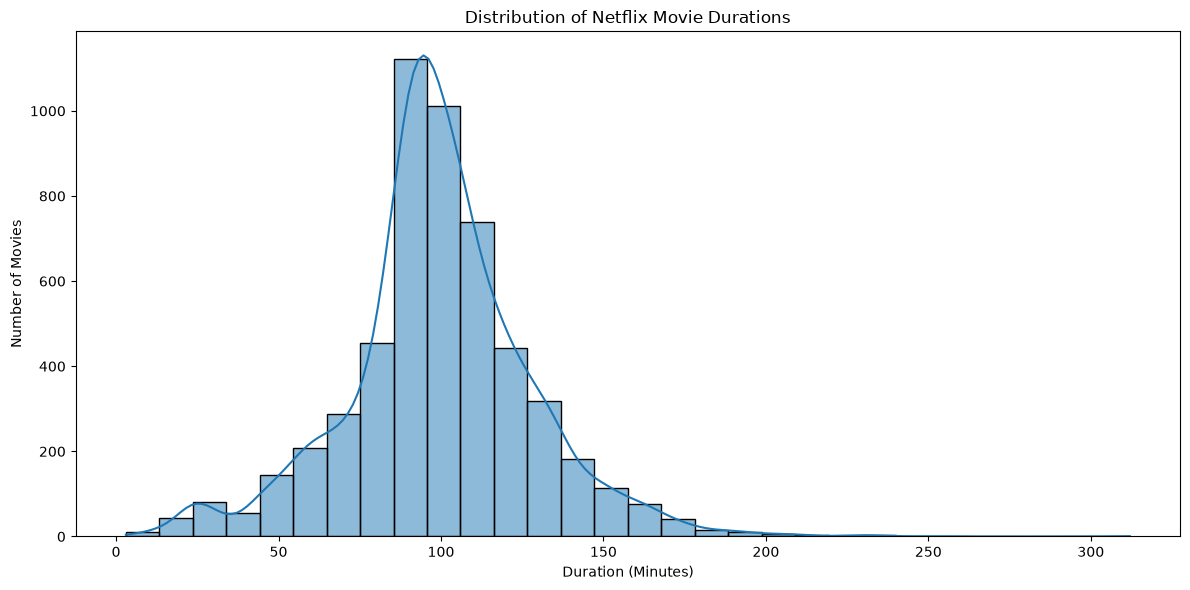

In [54]:
plt.figure(figsize=(12, 6))

sns.histplot(
    movie_duration['duration_minutes'],
    bins=30,
    kde=True
)

plt.title('Distribution of Netflix Movie Durations')
plt.xlabel('Duration (Minutes)')
plt.ylabel('Number of Movies')

plt.tight_layout()
plt.show()

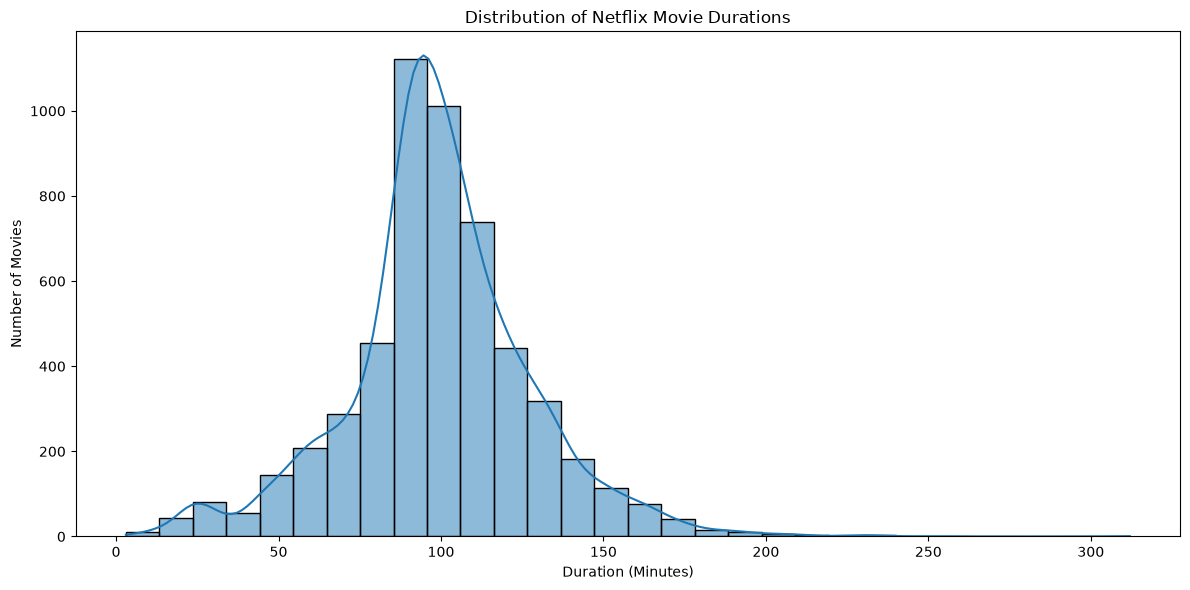

Graph saved successfully at:
c:\Users\shiva\OneDrive\Desktop\Company\DynamixNetworks_Netflix_Analysis\visualizations\movie_duration_distribution.png


In [55]:
graph_path = visualization_path / "movie_duration_distribution.png"

plt.figure(figsize=(12, 6))

sns.histplot(
    movie_duration['duration_minutes'],
    bins=30,
    kde=True
)

plt.title('Distribution of Netflix Movie Durations')
plt.xlabel('Duration (Minutes)')
plt.ylabel('Number of Movies')

plt.tight_layout()

plt.savefig(
    graph_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(f"Graph saved successfully at:\n{graph_path}")

In [56]:
tv_shows = df[
    (df['type'] == 'TV Show') &
    (df['duration_seasons'].notna())
].copy()

tv_shows['duration_seasons'].describe()

count    2410.000000
mean        1.775934
std         1.596359
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        16.000000
Name: duration_seasons, dtype: float64

In [57]:
print("TV Shows analyzed:",
      len(tv_shows))

print("Average seasons:",
      round(tv_shows['duration_seasons'].mean(), 2))

print("Median seasons:",
      tv_shows['duration_seasons'].median())

print("Minimum seasons:",
      tv_shows['duration_seasons'].min())

print("Maximum seasons:",
      tv_shows['duration_seasons'].max())

TV Shows analyzed: 2410
Average seasons: 1.78
Median seasons: 1.0
Minimum seasons: 1.0
Maximum seasons: 16.0


In [58]:
season_counts = (
    tv_shows['duration_seasons']
    .value_counts()
    .sort_index()
)

season_counts

duration_seasons
1.0     1608
2.0      382
3.0      184
4.0       87
5.0       58
6.0       30
7.0       19
8.0       18
9.0        8
10.0       6
11.0       3
12.0       2
13.0       2
15.0       2
16.0       1
Name: count, dtype: int64

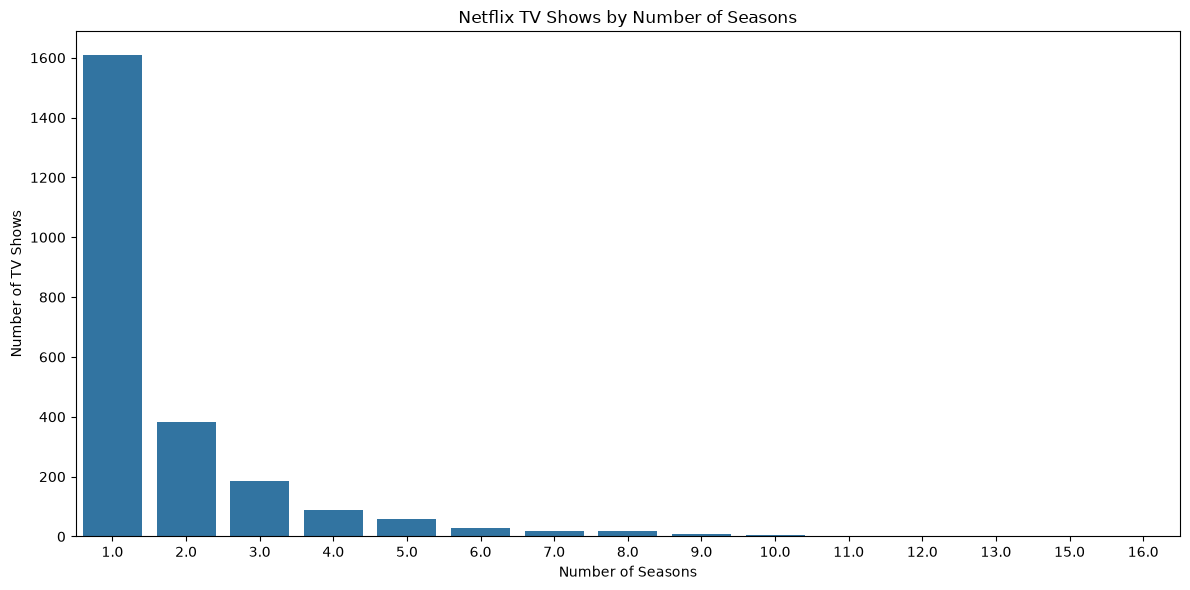

In [59]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=season_counts.index,
    y=season_counts.values
)

plt.title('Netflix TV Shows by Number of Seasons')
plt.xlabel('Number of Seasons')
plt.ylabel('Number of TV Shows')

plt.tight_layout()
plt.show()

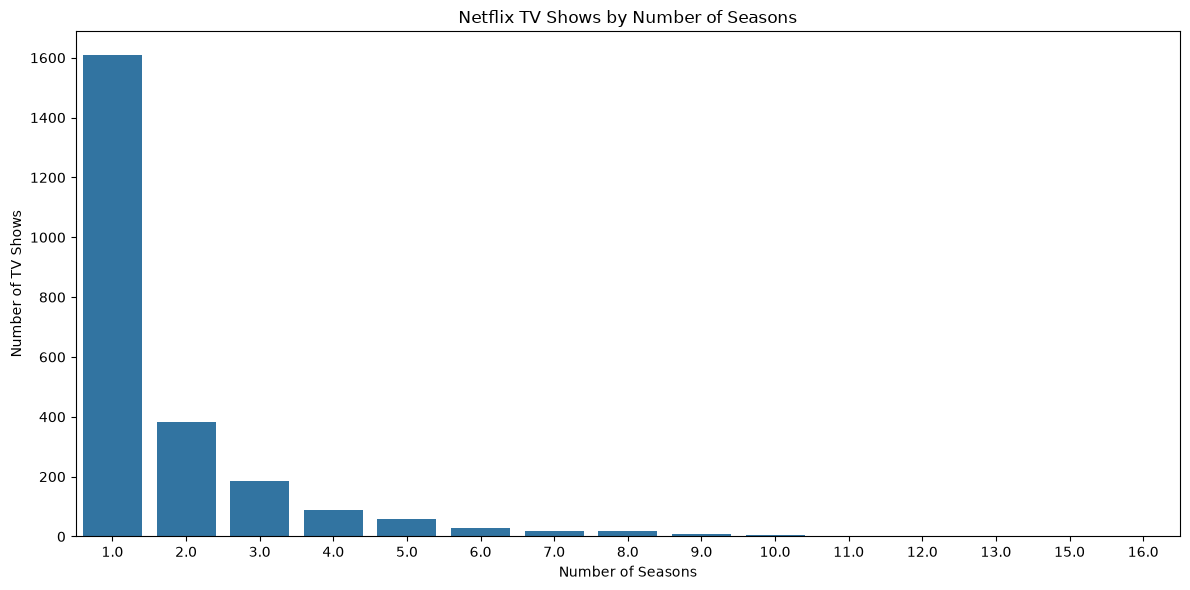

Graph saved successfully at:
c:\Users\shiva\OneDrive\Desktop\Company\DynamixNetworks_Netflix_Analysis\visualizations\tv_shows_by_seasons.png


In [60]:
graph_path = visualization_path / "tv_shows_by_seasons.png"

plt.figure(figsize=(12, 6))

sns.barplot(
    x=season_counts.index,
    y=season_counts.values
)

plt.title('Netflix TV Shows by Number of Seasons')
plt.xlabel('Number of Seasons')
plt.ylabel('Number of TV Shows')

plt.tight_layout()

plt.savefig(
    graph_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(f"Graph saved successfully at:\n{graph_path}")

In [61]:
eda_summary = {
    'Total Titles': len(df),
    'Movies': (df['type'] == 'Movie').sum(),
    'TV Shows': (df['type'] == 'TV Show').sum(),
    'Most Common Rating': df['rating'].mode()[0],
    'Most Common Genre': genre_counts.index[0],
    'Top Country': country_counts.index[0],
    'Average Movie Duration': round(movie_duration['duration_minutes'].mean(), 2),
    'Median Movie Duration': movie_duration['duration_minutes'].median(),
    'Average TV Show Seasons': round(tv_shows['duration_seasons'].mean(), 2)
}

eda_summary

{'Total Titles': 7787,
 'Movies': np.int64(5377),
 'TV Shows': np.int64(2410),
 'Most Common Rating': 'TV-MA',
 'Most Common Genre': 'International Movies',
 'Top Country': 'United States',
 'Average Movie Duration': np.float64(99.31),
 'Median Movie Duration': np.float64(98.0),
 'Average TV Show Seasons': np.float64(1.78)}

In [62]:
list(visualization_path.glob("*.png"))

[WindowsPath('c:/Users/shiva/OneDrive/Desktop/Company/DynamixNetworks_Netflix_Analysis/visualizations/content_by_release_year.png'),
 WindowsPath('c:/Users/shiva/OneDrive/Desktop/Company/DynamixNetworks_Netflix_Analysis/visualizations/content_by_type.png'),
 WindowsPath('c:/Users/shiva/OneDrive/Desktop/Company/DynamixNetworks_Netflix_Analysis/visualizations/movie_duration_distribution.png'),
 WindowsPath('c:/Users/shiva/OneDrive/Desktop/Company/DynamixNetworks_Netflix_Analysis/visualizations/netflix_content_by_rating.png'),
 WindowsPath('c:/Users/shiva/OneDrive/Desktop/Company/DynamixNetworks_Netflix_Analysis/visualizations/netflix_titles_added_by_year.png'),
 WindowsPath('c:/Users/shiva/OneDrive/Desktop/Company/DynamixNetworks_Netflix_Analysis/visualizations/top_15_netflix_countries.png'),
 WindowsPath('c:/Users/shiva/OneDrive/Desktop/Company/DynamixNetworks_Netflix_Analysis/visualizations/top_15_netflix_genres.png'),
 WindowsPath('c:/Users/shiva/OneDrive/Desktop/Company/DynamixNetwor

In [63]:
eda_summary

{'Total Titles': 7787,
 'Movies': np.int64(5377),
 'TV Shows': np.int64(2410),
 'Most Common Rating': 'TV-MA',
 'Most Common Genre': 'International Movies',
 'Top Country': 'United States',
 'Average Movie Duration': np.float64(99.31),
 'Median Movie Duration': np.float64(98.0),
 'Average TV Show Seasons': np.float64(1.78)}

In [64]:
yearly_additions = (
    df.groupby('date_added_year')
      .size()
      .reset_index(name='titles_added')
      .sort_values('date_added_year')
)

yearly_additions

,date_added_year,titles_added
0,2008.0,2
1,2009.0,2
2,2010.0,1
3,2011.0,13
4,2012.0,3
5,2013.0,11
6,2014.0,25
7,2015.0,88
8,2016.0,443
9,2017.0,1225


In [65]:
yearly_additions['yoy_growth_%'] = (
    yearly_additions['titles_added']
    .pct_change()
    .mul(100)
    .round(2)
)

yearly_additions

,date_added_year,titles_added,yoy_growth_%
0,2008.0,2,NaN
1,2009.0,2,0.00
2,2010.0,1,-50.00
3,2011.0,13,1200.00
4,2012.0,3,-76.92
5,2013.0,11,266.67
6,2014.0,25,127.27
7,2015.0,88,252.00
8,2016.0,443,403.41
9,2017.0,1225,176.52


In [66]:
growth_analysis = (
    yearly_additions
    .dropna(subset=['yoy_growth_%'])
    .sort_values('yoy_growth_%', ascending=False)
)

growth_analysis.head(10)

,date_added_year,titles_added,yoy_growth_%
3,2011.0,13,1200.00
8,2016.0,443,403.41
5,2013.0,11,266.67
7,2015.0,88,252.00
9,2017.0,1225,176.52
6,2014.0,25,127.27
10,2018.0,1685,37.55
11,2019.0,2153,27.77
1,2009.0,2,0.00
12,2020.0,2009,-6.69


In [67]:
decline_analysis = (
    yearly_additions
    .dropna(subset=['yoy_growth_%'])
    .sort_values('yoy_growth_%')
)

decline_analysis.head(10)

,date_added_year,titles_added,yoy_growth_%
13,2021.0,117,-94.18
4,2012.0,3,-76.92
2,2010.0,1,-50.00
12,2020.0,2009,-6.69
1,2009.0,2,0.00
11,2019.0,2153,27.77
10,2018.0,1685,37.55
6,2014.0,25,127.27
9,2017.0,1225,176.52
7,2015.0,88,252.00


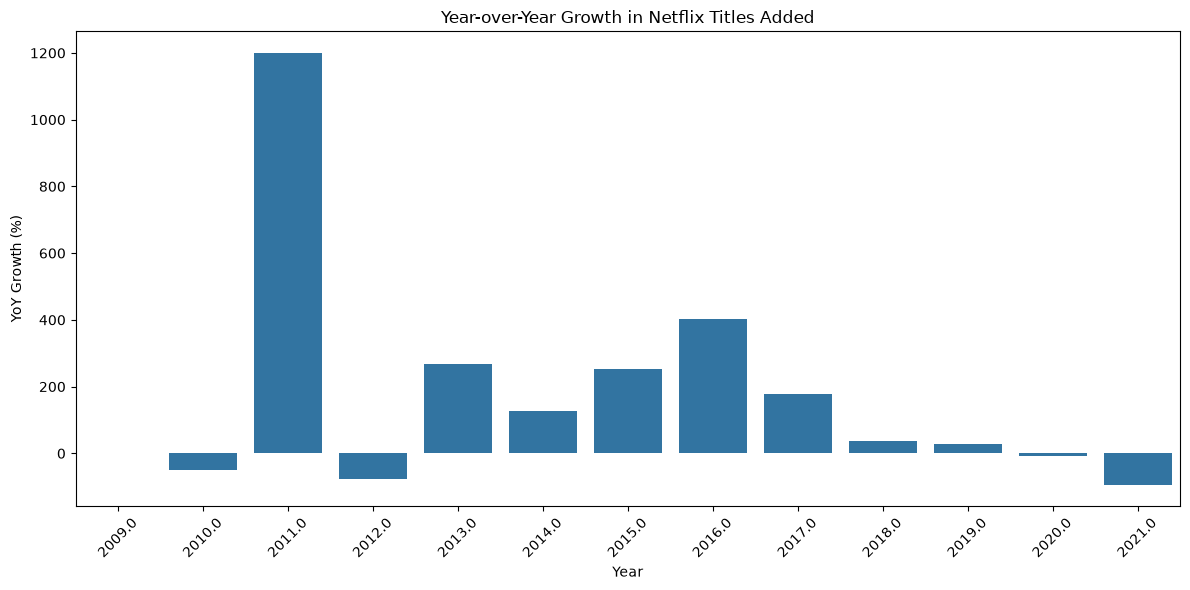

In [68]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=yearly_additions.dropna(),
    x='date_added_year',
    y='yoy_growth_%'
)

plt.title('Year-over-Year Growth in Netflix Titles Added')
plt.xlabel('Year')
plt.ylabel('YoY Growth (%)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

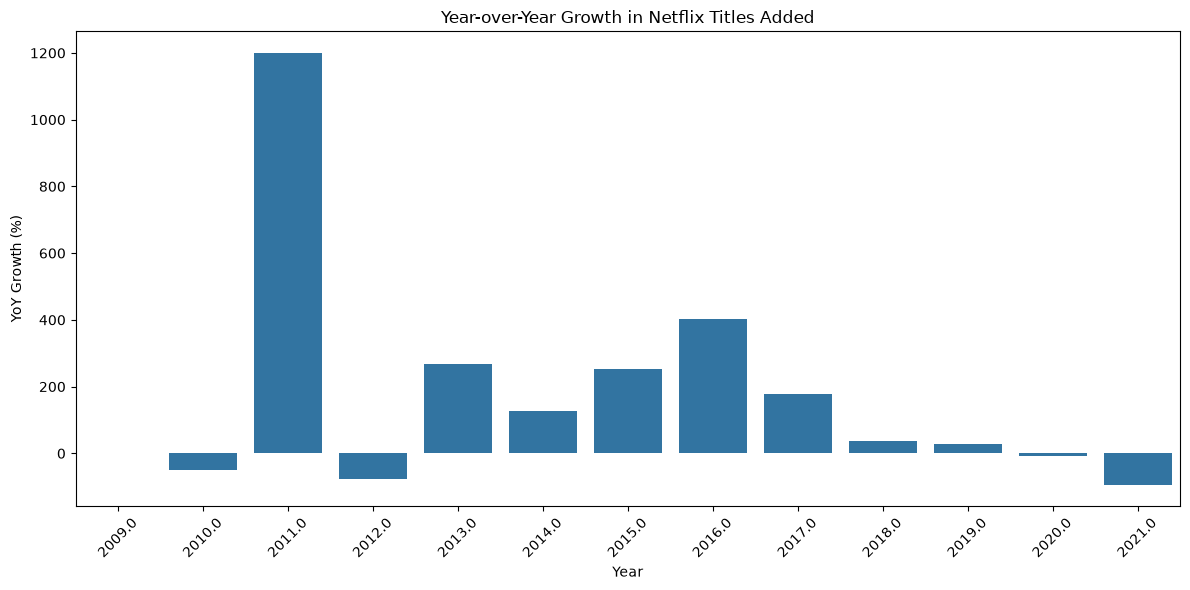

Graph saved successfully at:
c:\Users\shiva\OneDrive\Desktop\Company\DynamixNetworks_Netflix_Analysis\visualizations\yoy_content_growth.png


In [69]:
graph_path = visualization_path / "yoy_content_growth.png"

plt.figure(figsize=(12, 6))

sns.barplot(
    data=yearly_additions.dropna(),
    x='date_added_year',
    y='yoy_growth_%'
)

plt.title('Year-over-Year Growth in Netflix Titles Added')
plt.xlabel('Year')
plt.ylabel('YoY Growth (%)')
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    graph_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(f"Graph saved successfully at:\n{graph_path}")

In [70]:
type_by_year = (
    df.groupby(['date_added_year', 'type'])
      .size()
      .reset_index(name='titles_added')
      .sort_values(['date_added_year', 'type'])
)

type_by_year

,date_added_year,type,titles_added
0,2008.0,Movie,1
1,2008.0,TV Show,1
2,2009.0,Movie,2
3,2010.0,Movie,1
4,2011.0,Movie,13
5,2012.0,Movie,3
6,2013.0,Movie,6
7,2013.0,TV Show,5
8,2014.0,Movie,19
9,2014.0,TV Show,6


In [71]:
type_by_year['year_total'] = (
    type_by_year
    .groupby('date_added_year')['titles_added']
    .transform('sum')
)

type_by_year['percentage'] = (
    type_by_year['titles_added']
    .div(type_by_year['year_total'])
    .mul(100)
    .round(2)
)

type_by_year

,date_added_year,type,titles_added,year_total,percentage
0,2008.0,Movie,1,2,50.00
1,2008.0,TV Show,1,2,50.00
2,2009.0,Movie,2,2,100.00
3,2010.0,Movie,1,1,100.00
4,2011.0,Movie,13,13,100.00
5,2012.0,Movie,3,3,100.00
6,2013.0,Movie,6,11,54.55
7,2013.0,TV Show,5,11,45.45
8,2014.0,Movie,19,25,76.00
9,2014.0,TV Show,6,25,24.00


In [72]:
type_share = (
    type_by_year
    .pivot(
        index='date_added_year',
        columns='type',
        values='percentage'
    )
    .fillna(0)
)

type_share

type,Movie,TV Show
date_added_year,,
2008.0,50.00,50.00
2009.0,100.00,0.00
2010.0,100.00,0.00
2011.0,100.00,0.00
2012.0,100.00,0.00
2013.0,54.55,45.45
2014.0,76.00,24.00
2015.0,65.91,34.09
2016.0,58.24,41.76


In [73]:
type_share.tail(10)

type,Movie,TV Show
date_added_year,,
2012.0,100.00,0.00
2013.0,54.55,45.45
2014.0,76.00,24.00
2015.0,65.91,34.09
2016.0,58.24,41.76
2017.0,70.53,29.47
2018.0,74.48,25.52
2019.0,69.53,30.47
2020.0,65.31,34.69


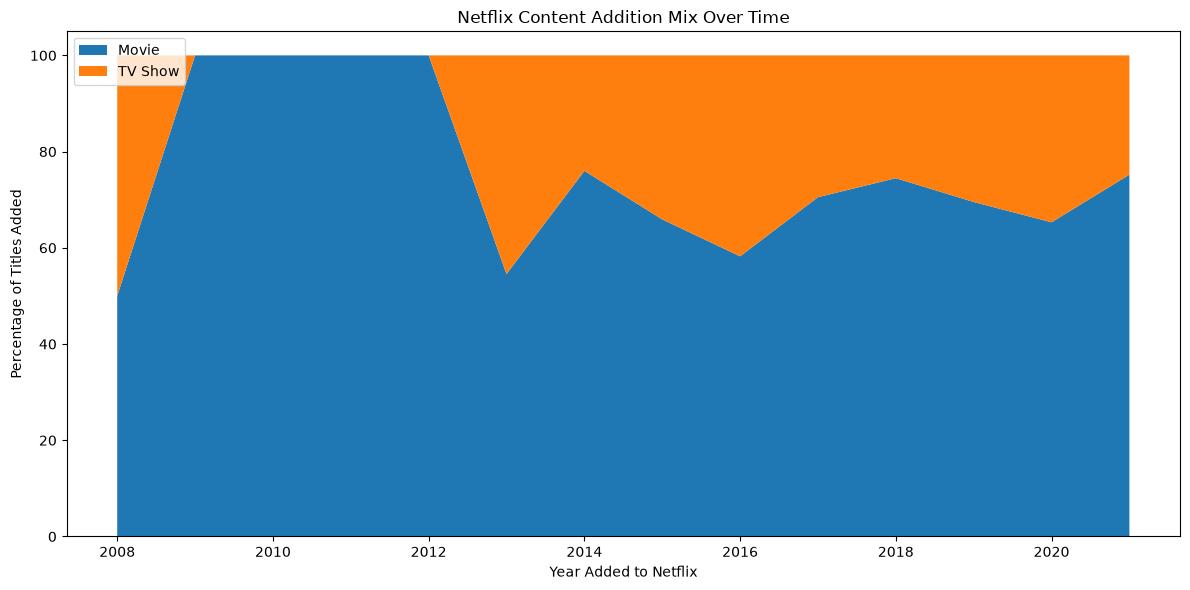

In [74]:
plt.figure(figsize=(12, 6))

plt.stackplot(
    type_share.index,
    type_share['Movie'],
    type_share['TV Show'],
    labels=['Movie', 'TV Show']
)

plt.title('Netflix Content Addition Mix Over Time')
plt.xlabel('Year Added to Netflix')
plt.ylabel('Percentage of Titles Added')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

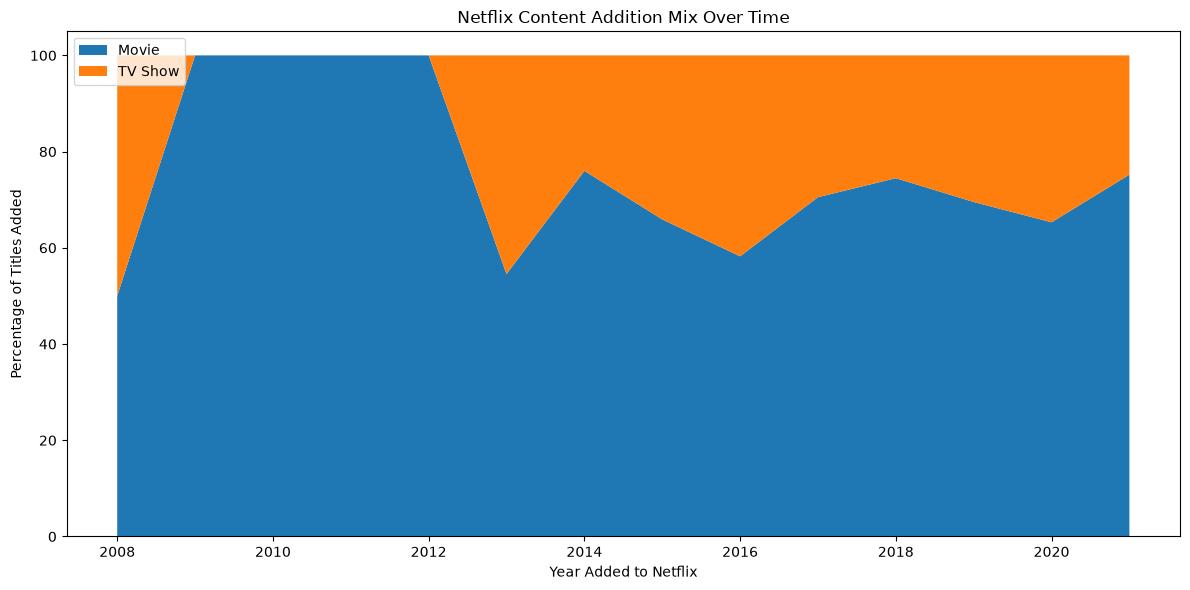

Graph saved successfully at:
c:\Users\shiva\OneDrive\Desktop\Company\DynamixNetworks_Netflix_Analysis\visualizations\movie_vs_tv_content_mix.png


In [75]:
graph_path = visualization_path / "movie_vs_tv_content_mix.png"

plt.figure(figsize=(12, 6))

plt.stackplot(
    type_share.index,
    type_share['Movie'],
    type_share['TV Show'],
    labels=['Movie', 'TV Show']
)

plt.title('Netflix Content Addition Mix Over Time')
plt.xlabel('Year Added to Netflix')
plt.ylabel('Percentage of Titles Added')
plt.legend(loc='upper left')

plt.tight_layout()

plt.savefig(
    graph_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(f"Graph saved successfully at:\n{graph_path}")

In [76]:
type_share

type,Movie,TV Show
date_added_year,,
2008.0,50.00,50.00
2009.0,100.00,0.00
2010.0,100.00,0.00
2011.0,100.00,0.00
2012.0,100.00,0.00
2013.0,54.55,45.45
2014.0,76.00,24.00
2015.0,65.91,34.09
2016.0,58.24,41.76


In [77]:
country_genre_df = df[['show_id', 'country', 'listed_in']].copy()

country_genre_df['country'] = country_genre_df['country'].str.split(',')
country_genre_df = country_genre_df.explode('country')

country_genre_df['genre'] = country_genre_df['listed_in'].str.split(',')
country_genre_df = country_genre_df.explode('genre')

country_genre_df['country'] = country_genre_df['country'].str.strip()
country_genre_df['genre'] = country_genre_df['genre'].str.strip()

country_genre_df.head(10)

,show_id,country,listed_in,genre
0,s1,Brazil,"International TV Shows, TV Dramas, TV Sci-Fi &...",International TV Shows
0,s1,Brazil,"International TV Shows, TV Dramas, TV Sci-Fi &...",TV Dramas
0,s1,Brazil,"International TV Shows, TV Dramas, TV Sci-Fi &...",TV Sci-Fi & Fantasy
1,s2,Mexico,"Dramas, International Movies",Dramas
1,s2,Mexico,"Dramas, International Movies",International Movies
2,s3,Singapore,"Horror Movies, International Movies",Horror Movies
2,s3,Singapore,"Horror Movies, International Movies",International Movies
3,s4,United States,"Action & Adventure, Independent Movies, Sci-Fi...",Action & Adventure
3,s4,United States,"Action & Adventure, Independent Movies, Sci-Fi...",Independent Movies
3,s4,United States,"Action & Adventure, Independent Movies, Sci-Fi...",Sci-Fi & Fantasy


In [78]:
country_genre_analysis = country_genre_df[
    country_genre_df['country'] != 'Not Specified'
].copy()

In [79]:
us_genres = (
    country_genre_analysis[
        country_genre_analysis['country'] == 'United States'
    ]['genre']
    .value_counts()
    .head(10)
)

us_genres

genre
Dramas                      716
Comedies                    588
Documentaries               478
Independent Movies          358
Children & Family Movies    348
Action & Adventure          315
Thrillers                   251
TV Comedies                 238
TV Dramas                   221
Stand-Up Comedy             212
Name: count, dtype: int64

In [80]:
india_genres = (
    country_genre_analysis[
        country_genre_analysis['country'] == 'India'
    ]['genre']
    .value_counts()
    .head(10)
)

india_genres

genre
International Movies      828
Dramas                    626
Comedies                  308
Independent Movies        145
Action & Adventure        134
Romantic Movies           113
Music & Musicals           97
Thrillers                  88
International TV Shows     60
Horror Movies              34
Name: count, dtype: int64

In [81]:
comparison = pd.concat(
    [
        us_genres.rename('United States'),
        india_genres.rename('India')
    ],
    axis=1
).fillna(0)

comparison

,United States,India
genre,,
Dramas,716.0,626.0
Comedies,588.0,308.0
Documentaries,478.0,0.0
Independent Movies,358.0,145.0
Children & Family Movies,348.0,0.0
Action & Adventure,315.0,134.0
Thrillers,251.0,88.0
TV Comedies,238.0,0.0
TV Dramas,221.0,0.0


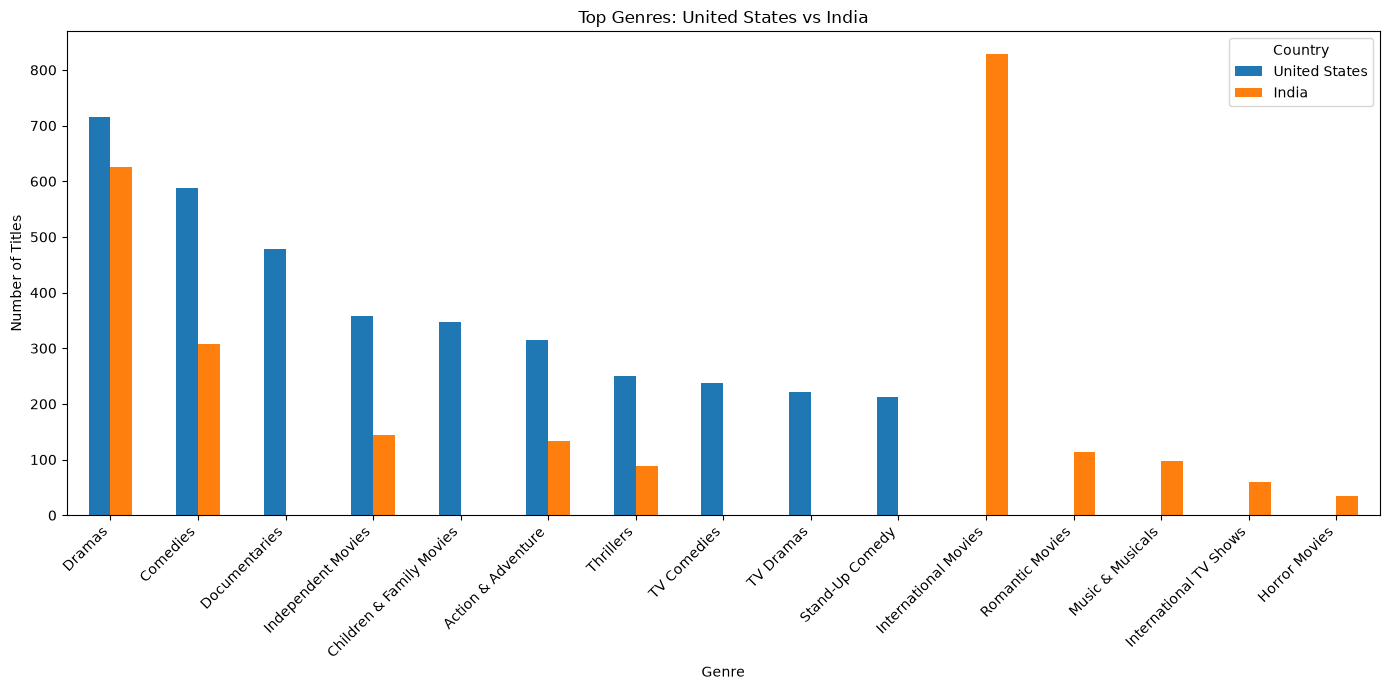

In [82]:
comparison.plot(
    kind='bar',
    figsize=(14, 7)
)

plt.title('Top Genres: United States vs India')
plt.xlabel('Genre')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Country')

plt.tight_layout()
plt.show()

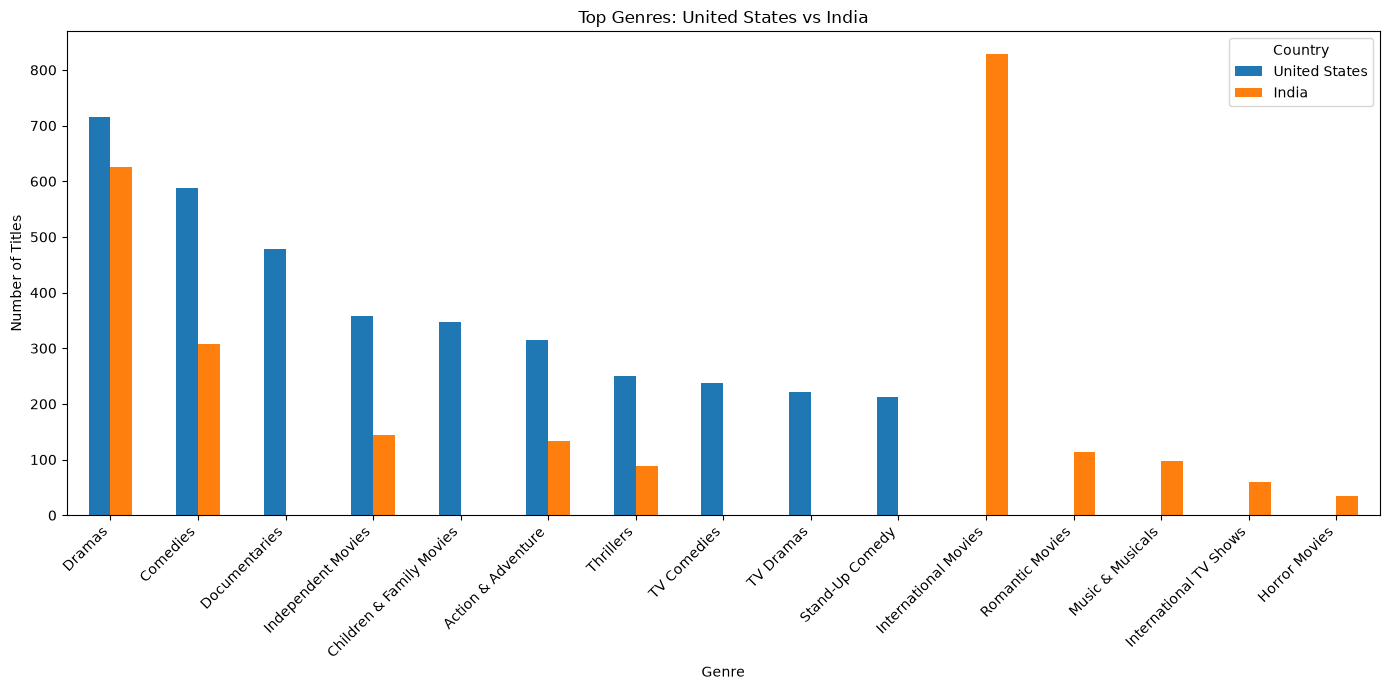

Graph saved successfully at:
c:\Users\shiva\OneDrive\Desktop\Company\DynamixNetworks_Netflix_Analysis\visualizations\us_vs_india_genres.png


In [83]:
graph_path = visualization_path / "us_vs_india_genres.png"

comparison.plot(
    kind='bar',
    figsize=(14, 7)
)

plt.title('Top Genres: United States vs India')
plt.xlabel('Genre')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Country')

plt.tight_layout()

plt.savefig(
    graph_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(f"Graph saved successfully at:\n{graph_path}")

In [88]:
rating_type_percentage = (
    rating_type_counts
    .div(rating_type_counts.sum(axis=0), axis=1)
    .mul(100)
    .round(2)
)

rating_type_percentage

type,Movie,TV Show
rating,,
G,0.73,0.00
NC-17,0.06,0.00
NR,1.47,0.21
Not Rated,0.09,0.08
PG,4.59,0.00
PG-13,7.18,0.00
R,12.33,0.08
TV-14,23.66,27.34
TV-G,2.06,3.44


In [89]:
rating_type_percentage = (
    rating_type_counts
    .div(rating_type_counts.sum(axis=0), axis=1)
    .mul(100)
    .round(2)
)

rating_type_percentage

type,Movie,TV Show
rating,,
G,0.73,0.00
NC-17,0.06,0.00
NR,1.47,0.21
Not Rated,0.09,0.08
PG,4.59,0.00
PG-13,7.18,0.00
R,12.33,0.08
TV-14,23.66,27.34
TV-G,2.06,3.44


In [90]:
for content_type in rating_type_counts.columns:
    rating = rating_type_counts[content_type].idxmax()
    count = rating_type_counts[content_type].max()
    
    print(
        f"{content_type}: {rating} ({count} titles)"
    )

Movie: TV-MA (1845 titles)
TV Show: TV-MA (1018 titles)


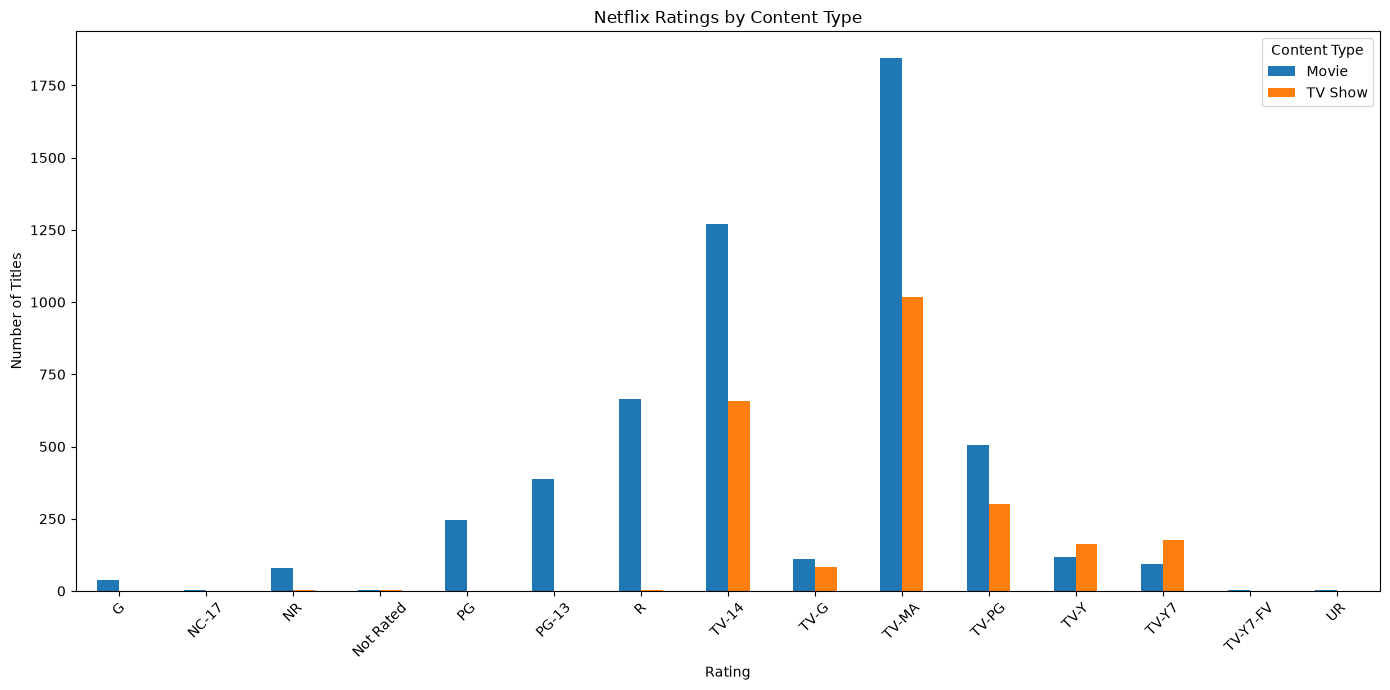

In [91]:
rating_type_counts.plot(
    kind='bar',
    figsize=(14, 7)
)

plt.title('Netflix Ratings by Content Type')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.legend(title='Content Type')

plt.tight_layout()
plt.show()

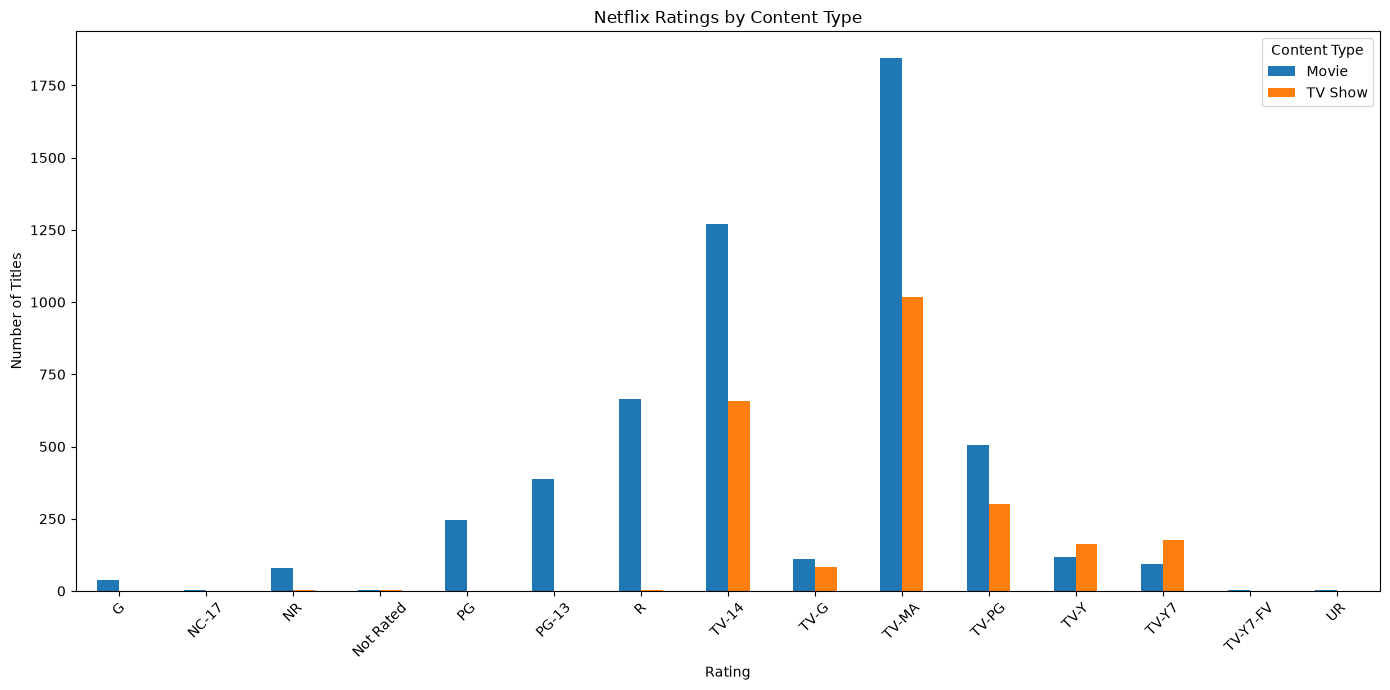

Graph saved successfully at:
c:\Users\shiva\OneDrive\Desktop\Company\DynamixNetworks_Netflix_Analysis\visualizations\ratings_by_content_type.png


In [92]:
graph_path = visualization_path / "ratings_by_content_type.png"

rating_type_counts.plot(
    kind='bar',
    figsize=(14, 7)
)

plt.title('Netflix Ratings by Content Type')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.legend(title='Content Type')

plt.tight_layout()

plt.savefig(
    graph_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(f"Graph saved successfully at:\n{graph_path}")

In [95]:
advanced_insights = {
    'Peak_year_for_titles_added': int(
        yearly_additions.loc[
            yearly_additions['titles_added'].idxmax(),
            'date_added_year'
        ]
    ),

    'Peak_titles_added': int(
        yearly_additions['titles_added'].max()
    ),

    'Highest_TV_Show_share_year': int(
        type_share['TV Show'].idxmax()
    ),

    'Highest_TV_Show_share': round(
        type_share['TV Show'].max(), 2
    ),

    'Top_US_genre': us_genres.index[0],

    'Top_US_genre_count': int(us_genres.iloc[0]),

    'Top_India_genre': india_genres.index[0],

    'Top_India_genre_count': int(india_genres.iloc[0]),

    'Movie_top_rating': rating_type_counts['Movie'].idxmax(),

    'TV_Show_top_rating': rating_type_counts['TV Show'].idxmax()
}

advanced_insights

{'Peak_year_for_titles_added': 2019,
 'Peak_titles_added': 2153,
 'Highest_TV_Show_share_year': 2008,
 'Highest_TV_Show_share': np.float64(50.0),
 'Top_US_genre': 'Dramas',
 'Top_US_genre_count': 716,
 'Top_India_genre': 'International Movies',
 'Top_India_genre_count': 828,
 'Movie_top_rating': 'TV-MA',
 'TV_Show_top_rating': 'TV-MA'}

In [96]:
business_insights = pd.DataFrame({
    'Analysis': [
        'Content Type',
        'Content Addition Trend',
        'Top Genre',
        'Top Country',
        'Movie Duration',
        'TV Show Seasons',
        'Movie Rating',
        'TV Show Rating'
    ],
    'Finding': [
        'Movies dominate the catalog',
        '2019 had the highest number of titles added',
        'International Movies is the most common genre',
        'United States has the highest country representation',
        'Average movie duration is approximately 99 minutes',
        'Average TV Show has approximately 1.78 seasons',
        'TV-MA is the most common Movie rating',
        'TV-MA is the most common TV Show rating'
    ],
    'Value': [
        '5,377 Movies vs 2,410 TV Shows',
        '2,153 titles added in 2019',
        '2,437 titles',
        '3,297 titles',
        '99.31 minutes',
        '1.78 seasons',
        '1,845 Movies',
        '1,018 TV Shows'
    ]
})

business_insights

,Analysis,Finding,Value
0,Content Type,Movies dominate the catalog,"5,377 Movies vs 2,410 TV Shows"
1,Content Addition Trend,2019 had the highest number of titles added,"2,153 titles added in 2019"
2,Top Genre,International Movies is the most common genre,"2,437 titles"
3,Top Country,United States has the highest country represen...,"3,297 titles"
4,Movie Duration,Average movie duration is approximately 99 min...,99.31 minutes
5,TV Show Seasons,Average TV Show has approximately 1.78 seasons,1.78 seasons
6,Movie Rating,TV-MA is the most common Movie rating,"1,845 Movies"
7,TV Show Rating,TV-MA is the most common TV Show rating,"1,018 TV Shows"


In [97]:
recommendations = pd.DataFrame({
    'Area': [
        'Content Strategy',
        'International Content',
        'Genre Strategy',
        'Audience Targeting',
        'Content Format',
        'Regional Strategy'
    ],
    'Recommendation': [
        'Maintain a balanced content portfolio while monitoring the changing share of Movies and TV Shows.',
        'Continue evaluating international content because International Movies is the largest individual genre.',
        'Use genre-level performance analysis to identify strong and underserved content categories.',
        'Use rating distributions to understand mature vs family-oriented content segments.',
        'Evaluate movie duration and TV Show season patterns when planning or acquiring content.',
        'Develop region-specific content strategies based on country-level genre preferences.'
    ]
})

recommendations

,Area,Recommendation
0,Content Strategy,Maintain a balanced content portfolio while mo...
1,International Content,Continue evaluating international content beca...
2,Genre Strategy,Use genre-level performance analysis to identi...
3,Audience Targeting,Use rating distributions to understand mature ...
4,Content Format,Evaluate movie duration and TV Show season pat...
5,Regional Strategy,Develop region-specific content strategies bas...


In [98]:
reports_path = project_path / "reports"
reports_path.mkdir(exist_ok=True)

In [99]:
business_insights.to_csv(
    reports_path / "business_insights.csv",
    index=False
)

recommendations.to_csv(
    reports_path / "recommendations.csv",
    index=False
)

print("Business insights and recommendations saved successfully.")

Business insights and recommendations saved successfully.


In [100]:
executive_summary = """
Netflix Content Analysis — Executive Summary

The dataset contains 7,787 Netflix titles, including 5,377 Movies
and 2,410 TV Shows. Movies represent the majority of the catalog.

Content additions increased substantially over the observed period,
with 2019 recording the highest number of titles added to Netflix
at 2,153 titles.

International Movies is the most common individual genre, followed
by Dramas and Comedies. The United States has the highest country
representation after separating multi-country records.

TV-MA is the most common rating for both Movies and TV Shows.
Among Movies, the average duration is approximately 99.31 minutes,
while TV Shows have an average duration of approximately 1.78 seasons.

The analysis also shows differences in content profiles between
countries. Dramas are the leading genre among titles associated
with the United States, while International Movies are the leading
genre among titles associated with India.

Overall, the analysis provides insights into Netflix's content mix,
content-addition trends, ratings, genres, geographic distribution,
movie duration, and TV Show season patterns.
"""

print(executive_summary)


Netflix Content Analysis — Executive Summary

The dataset contains 7,787 Netflix titles, including 5,377 Movies
and 2,410 TV Shows. Movies represent the majority of the catalog.

Content additions increased substantially over the observed period,
with 2019 recording the highest number of titles added to Netflix
at 2,153 titles.

International Movies is the most common individual genre, followed
by Dramas and Comedies. The United States has the highest country
representation after separating multi-country records.

TV-MA is the most common rating for both Movies and TV Shows.
Among Movies, the average duration is approximately 99.31 minutes,
while TV Shows have an average duration of approximately 1.78 seasons.

The analysis also shows differences in content profiles between
countries. Dramas are the leading genre among titles associated
with the United States, while International Movies are the leading
genre among titles associated with India.

Overall, the analysis provides insights 

In [101]:
from pathlib import Path

# Project folder
project_path = Path.cwd().parent

# Reports folder
reports_path = project_path / "reports"

# Create folder if it doesn't exist
reports_path.mkdir(exist_ok=True)

print("Reports folder:", reports_path)
print("Folder exists:", reports_path.exists())

Reports folder: c:\Users\shiva\OneDrive\Desktop\Company\DynamixNetworks_Netflix_Analysis\reports
Folder exists: True


In [102]:
summary_path = reports_path / "executive_summary.txt"

with open(summary_path, "w", encoding="utf-8") as file:
    file.write(executive_summary)

print(f"Executive summary saved successfully:")
print(summary_path)

Executive summary saved successfully:
c:\Users\shiva\OneDrive\Desktop\Company\DynamixNetworks_Netflix_Analysis\reports\executive_summary.txt


In [103]:
import pandas as pd
final_metrics = pd.DataFrame({
    'Metric': [
        'Total Titles',
        'Movies',
        'TV Shows',
        'Peak Year for Titles Added',
        'Peak Titles Added',
        'Most Common Rating',
        'Most Common Genre',
        'Top Country',
        'Average Movie Duration',
        'Median Movie Duration',
        'Average TV Show Seasons'
    ],
    'Value': [
        7787,
        5377,
        2410,
        2019,
        2153,
        'TV-MA',
        'International Movies',
        'United States',
        99.31,
        98.00,
        1.78
    ]
})

final_metrics

,Metric,Value
0,Total Titles,7787
1,Movies,5377
2,TV Shows,2410
3,Peak Year for Titles Added,2019
4,Peak Titles Added,2153
5,Most Common Rating,TV-MA
6,Most Common Genre,International Movies
7,Top Country,United States
8,Average Movie Duration,99.31
9,Median Movie Duration,98.0


In [104]:
final_metrics.to_csv(
    reports_path / "final_metrics.csv",
    index=False
)

print("Final metrics saved successfully.")

Final metrics saved successfully.
